In [249]:
from pathlib import Path
from PIL import Image
import cv2
import random
import wget
import numpy as np
from minerva.data.readers.png_reader import PNGReader
from minerva.data.readers.patched_array_reader import NumpyArrayReader
from minerva.data.data_modules.base import MinervaDataModule
from minerva.models.nets.image.deeplabv3 import DeepLabV3

from minerva.transforms.transform import _Transform, Identity
from minerva.transforms.random_transform import _RandomSyncedTransform, RandomFlip, RandomGrayScale, RandomSolarize, RandomRotation
from minerva.data.datasets.base import SimpleDataset

from minerva.analysis.model_analysis import TSNEAnalysis
from minerva.analysis.complexity_performance_analysis import ComplexityPerformanceAnalysis
from minerva.analysis.metrics.pixel_accuracy import PixelAccuracy

from minerva.utils.tensor import to_tensor

from minerva.models.ssl.byol import BYOL
from torchvision import transforms
import lightning as L
import torch
from torchmetrics import JaccardIndex
import matplotlib.pyplot as plt
import torchvision.models as models
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassJaccardIndex
import torchvision.transforms.functional as F
from torchvision.models import resnet50
import torch.nn as nn

In [95]:
class Identity_2(_Transform):
    """This class is a dummy transform that does nothing. It is useful when
    you want to skip a transform in a pipeline.
    """

    def __call__(self, x: np.ndarray) -> np.ndarray:
        x_out = to_tensor(x)
        x_out = x_out.permute(2, 0, 1)
        return x_out

    def __str__(self) -> str:
        return "Identity()"

In [125]:
class Identity_2(_Transform):
    """This class is a dummy transform that does nothing. It is useful when
    you want to skip a transform in a pipeline.
    """

    def __call__(self, x: np.ndarray) -> np.ndarray:
        transform = transforms.ToTensor()
        return transform(x)

    def __str__(self) -> str:
        return "Identity()"

In [126]:
class Format_label_img(_Transform):

    def __call__(self, x: np.ndarray) -> torch.Tensor:
        
        if x.ndim == 3:
            x = x.squeeze()

        label_tensor = torch.from_numpy(x).long()
    
        if label_tensor.min() >= 1:
            label_tensor = label_tensor - 1
    
        return label_tensor

In [254]:
def convert_resnet_for_deeplab(resnet_backbone: nn.Sequential, output_stride: int = 16):
    """
    Modifies a ResNet backbone (from BYOL pretraining) for DeepLab use.

    Args:
        resnet_backbone (nn.Sequential): The backbone extracted from the BYOL model.
        output_stride (int): Desired output stride (typically 8 or 16).

    Returns:
        nn.Sequential: Modified backbone for DeepLab.
    """

    # Extract ResNet layers
    conv1 = resnet_backbone[0]  # Conv1
    bn1 = resnet_backbone[1]    # BN1
    relu = resnet_backbone[2]   # ReLU
    maxpool = resnet_backbone[3]  # MaxPool

    layer1 = resnet_backbone[4]  # Layer1
    layer2 = resnet_backbone[5]  # Layer2
    layer3 = resnet_backbone[6]  # Layer3
    layer4 = resnet_backbone[7]  # Layer4

    # Adjust layers for output stride
    if output_stride == 8:
        s = [(1, 2), (2, 1)]  # (stride, dilation) pairs
    elif output_stride == 16:
        s = [(2, 1), (1, 2)]
    else:
        raise ValueError("Output stride must be 8 or 16.")

    # Modify layer3 and layer4 for dilation
    def _replace_stride_with_dilation(layer, dilation):
        for n, m in layer.named_modules():
            if isinstance(m, nn.Conv2d) and m.stride == (2, 2):
                m.stride = (1, 1)
                if m.kernel_size == (3, 3):
                    m.dilation = (dilation, dilation)
                    m.padding = (dilation, dilation)

    _replace_stride_with_dilation(layer3, s[0][1])
    _replace_stride_with_dilation(layer4, s[1][1])

    # Assemble modified backbone
    modified_backbone = nn.Sequential(
        conv1, bn1, relu, maxpool,
        layer1,
        layer2,
        layer3,
        layer4
    )

    return modified_backbone

In [322]:
def copy_labels(dataset):
    second_column = [row[1] for row in dataset]
    
    return second_column

In [332]:
def pixel_accuracy(pred_mask, label):
    correct = (pred_mask == label).float()  # float for division
    acc = correct.sum() / correct.numel()   # total correct / total pixels
    return acc

In [263]:
train_fine_data_reader = PNGReader(
    path=Path('dataset_spectogram/train/data')
)

In [264]:
train_fine_labels_reader = PNGReader(
    path=Path('dataset_spectogram/train/label')
)

In [265]:
val_fine_data_reader = PNGReader(
    path=Path('dataset_spectogram/val/data')
)

In [266]:
val_fine_labels_reader = PNGReader(
    path=Path('dataset_spectogram/val/label')
)

In [267]:
test_fine_data_reader = PNGReader(
    path=Path('dataset_spectogram/test/data')
)

In [268]:
test_fine_labels_reader = PNGReader(
    path=Path('dataset_spectogram/test/label')
)

In [269]:
train_test_data_reader = PNGReader(
    path=Path('dataset_spectogram/train_test/data')
)

In [270]:
train_test_labels_reader = PNGReader(
    path=Path('dataset_spectogram/train_test/label')
)

In [271]:
train_fine_dataset = SimpleDataset(
    readers=[train_fine_data_reader, train_fine_labels_reader],
    transforms=[Identity_2(), Format_label_img()],
)

print(train_fine_dataset)

           📂 SimpleDataset Information            
📌 Dataset Type: SimpleDataset
   └── Reader 0: PNGReader at 'dataset_spectogram\train\data' (1842 files)
   │     └── Transform: Identity()
   └── Reader 1: PNGReader at 'dataset_spectogram\train\label' (1842 files)
   │     └── Transform: <__main__.Format_label_img object at 0x0000018052C10770>
   │
   └── Total Readers: 2


In [272]:
val_fine_dataset = SimpleDataset(
    readers=[val_fine_data_reader, val_fine_labels_reader],
    transforms=[Identity_2(), Format_label_img()],
)

print(val_fine_dataset)

           📂 SimpleDataset Information            
📌 Dataset Type: SimpleDataset
   └── Reader 0: PNGReader at 'dataset_spectogram\val\data' (525 files)
   │     └── Transform: Identity()
   └── Reader 1: PNGReader at 'dataset_spectogram\val\label' (525 files)
   │     └── Transform: <__main__.Format_label_img object at 0x00000180460E1460>
   │
   └── Total Readers: 2


In [273]:
test_fine_dataset = SimpleDataset(
    readers=[test_fine_data_reader, test_fine_labels_reader],
    transforms=[Identity_2(), Format_label_img()],
)

print(test_fine_dataset)

           📂 SimpleDataset Information            
📌 Dataset Type: SimpleDataset
   └── Reader 0: PNGReader at 'dataset_spectogram\test\data' (266 files)
   │     └── Transform: Identity()
   └── Reader 1: PNGReader at 'dataset_spectogram\test\label' (266 files)
   │     └── Transform: <__main__.Format_label_img object at 0x0000018052C11220>
   │
   └── Total Readers: 2


In [222]:
train_test_dataset = SimpleDataset(
    readers=[train_test_data_reader, train_test_labels_reader],
    transforms=[Identity_2(), Format_label_img()],
)

In [274]:
data_fine_module = MinervaDataModule(
    train_dataset=train_fine_dataset,
    val_dataset=val_fine_dataset,
    test_dataset=test_fine_dataset,
    batch_size=16,
    num_workers=0,
    #additional_train_dataloader_kwargs={"drop_last": True},
    name="simulated spectogram"
)

In [223]:
data_test_module = MinervaDataModule(
    train_dataset=train_test_dataset,
    batch_size=16,
    num_workers=0,
    #additional_train_dataloader_kwargs={"drop_last": True},
    name="simulated spectogram"
)

# backbone byol

In [275]:
resnet50_pretrained = models.resnet50(weights='DEFAULT')

In [276]:
resnet50_backbone = torch.nn.Sequential(*list(resnet50_pretrained.children())[:-1])
#byol_0_net50 = BYOL.load_from_checkpoint("byol_pretrained_0_resnet50.ckpt")
byol_0_net50 = BYOL.load_from_checkpoint("byol_pretrained_0_resnet50.ckpt", backbone=resnet50_backbone)

In [277]:
for param in byol_0_net50.backbone.parameters():
    param.requires_grad = True

In [278]:
_backbone_net50 = byol_0_net50.backbone

In [253]:
print(byol_0_net50.backbone)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [279]:
deeplab_backbone = convert_resnet_for_deeplab(byol_0_net50.backbone) 

In [280]:
model_fine_tuning = DeepLabV3(deeplab_backbone,learning_rate=1e-5,num_classes=3)
model_fine_tuning

DeepLabV3(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(6

In [281]:
trainer_fine_tuning = L.Trainer(
    max_epochs=20,
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
)

trainer_fine_tuning

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [282]:
trainer_fine_tuning.fit(model_fine_tuning, data_fine_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type                    | Params | Mode 
-------------------------------------------------------------
0 | backbone | Sequential              | 23.5 M | train
1 | fc       | DeepLabV3PredictionHead | 16.1 M | train
2 | loss_fn  | CrossEntropyLoss        | 0      | train
-------------------------------------------------------------
39.6 M    Trainable params
0         Non-trainable params
39.6 M    Total params
158.537   Total estimated model params size (MB)
183       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=20` reached.


In [334]:
predictions_backbone = trainer_fine_tuning.predict(model_fine_tuning, data_fine_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

In [336]:
predictions_backbone = torch.cat(predictions_backbone, dim=0)
pred_classes_backbone = torch.argmax(predictions_backbone, dim=1)
test_samples_backbone = np.array([y for _, y in data_fine_module.test_dataset])
y_backbone = torch.from_numpy(test_samples_backbone).long()

In [337]:
jaccard = JaccardIndex(task="multiclass", num_classes=3)
score = jaccard(pred_classes_backbone, y_backbone)
print(f"The mIoU of the model is {score.item()*100:.2f}%")

The mIoU of the model is 97.44%


In [338]:
acc = pixel_accuracy(pred_classes_backbone, y_backbone)
print(f"Pixel Accuracy: {acc.item():.4f}")

Pixel Accuracy: 0.9874


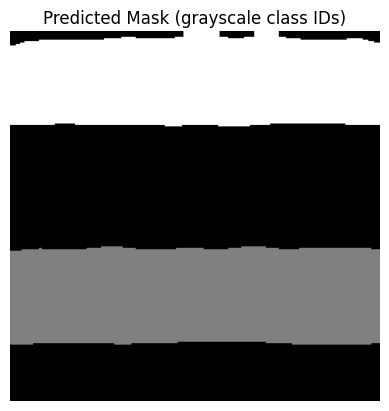

In [354]:
mask = pred_classes_backbone[1].cpu().numpy()  # shape [H, W]

# Display class indices (0, 1, 2)
plt.imshow(mask, cmap='gray')
plt.title("Predicted Mask (grayscale class IDs)")
plt.axis('off')
plt.show()

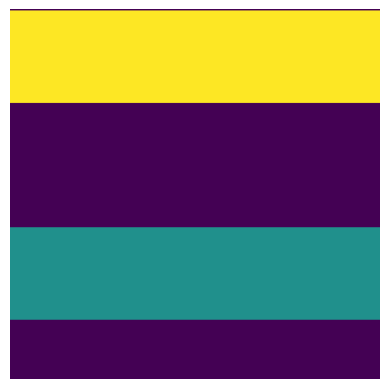

In [355]:
plt.imshow(test_fine_labels_reader[1])
plt.axis('off')  
plt.show()

In [17]:
resnet50_pretrained = models.resnet50(weights='DEFAULT')

# no backbone

In [283]:
model_no_backbone = DeepLabV3(num_classes=3)
model_no_backbone

DeepLabV3(
  (backbone): DeepLabV3Backbone(
    (RN50model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu)

In [284]:
trainer_no_backbone = L.Trainer(
    max_epochs=20,
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
)

trainer_no_backbone

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [285]:
trainer_no_backbone.fit(model_no_backbone, data_fine_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type                    | Params | Mode 
-------------------------------------------------------------
0 | backbone | DeepLabV3Backbone       | 25.6 M | train
1 | fc       | DeepLabV3PredictionHead | 16.1 M | train
2 | loss_fn  | CrossEntropyLoss        | 0      | train
-------------------------------------------------------------
41.7 M    Trainable params
0         Non-trainable params
41.7 M    Total params
166.733   Total estimated model params size (MB)
186       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=20` reached.


In [290]:
predictions_no_back_bone = trainer_no_backbone.predict(model_no_backbone, data_fine_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

In [298]:
predictions_no_back_bone = torch.cat(predictions_no_back_bone, dim=0)

In [313]:
print(predictions_no_back_bone.shape, predictions_no_back_bone.dtype)

torch.Size([266, 3, 256, 256]) torch.float32


In [300]:
pred_classes_no_backbone = torch.argmax(predictions_no_back_bone, dim=1)

In [330]:
print(pred_classes_no_backbone.shape, pred_classes_no_backbone.dtype)

torch.Size([266, 256, 256]) torch.int64


In [327]:
test_samples_no_backbone = np.array([y for _, y in data_fine_module.test_dataset])

In [328]:
y_no_backbone = torch.from_numpy(test_samples_no_backbone).long()

In [329]:
print(y_no_backbone.shape, y_no_backbone.dtype)

torch.Size([266, 256, 256]) torch.int64


In [331]:
jaccard = JaccardIndex(task="multiclass", num_classes=3)
score = jaccard(pred_classes_no_backbone, y_no_backbone)
print(f"The mIoU of the model is {score.item()*100:.2f}%")

The mIoU of the model is 98.92%


In [333]:
acc = pixel_accuracy(pred_classes_no_backbone, y_no_backbone)
print(f"Pixel Accuracy: {acc.item():.4f}")

Pixel Accuracy: 0.9951


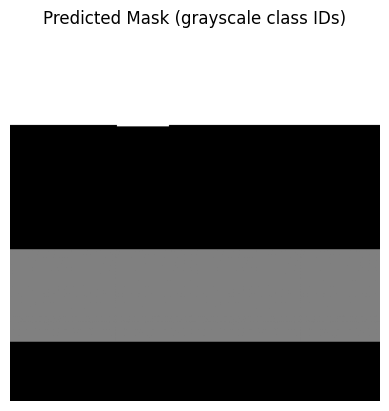

In [356]:
mask = pred_classes_no_backbone[1].cpu().numpy()  # shape [H, W]

# Display class indices (0, 1, 2)
plt.imshow(mask, cmap='gray')
plt.title("Predicted Mask (grayscale class IDs)")
plt.axis('off')
plt.show()

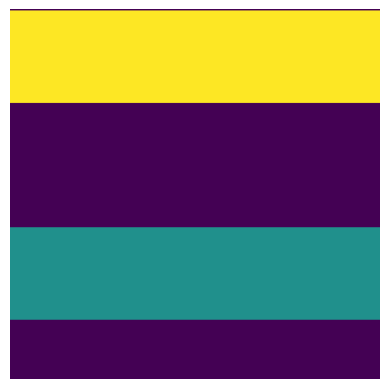

In [357]:
plt.imshow(test_fine_labels_reader[1])
plt.axis('off')  
plt.show()

# backbone byol freeze

In [339]:
resnet50_pretrained = models.resnet50(weights='DEFAULT')
resnet50_backbone = torch.nn.Sequential(*list(resnet50_pretrained.children())[:-1])
byol_0_net50 = BYOL.load_from_checkpoint("byol_pretrained_0_resnet50.ckpt", backbone=resnet50_backbone)
_backbone_net50 = byol_0_net50.backbone

In [340]:
deeplab_backbone = convert_resnet_for_deeplab(byol_0_net50.backbone) 

In [341]:
model_fine_tuning = DeepLabV3(deeplab_backbone,learning_rate=1e-5,num_classes=3)

In [342]:
for param in model_fine_tuning.backbone.parameters():
    param.requires_grad = False

In [344]:
trainer_freeze = L.Trainer(
    max_epochs=20,
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [345]:
trainer_freeze.fit(model_fine_tuning, data_fine_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type                    | Params | Mode 
-------------------------------------------------------------
0 | backbone | Sequential              | 23.5 M | train
1 | fc       | DeepLabV3PredictionHead | 16.1 M | train
2 | loss_fn  | CrossEntropyLoss        | 0      | train
-------------------------------------------------------------
16.1 M    Trainable params
23.5 M    Non-trainable params
39.6 M    Total params
158.537   Total estimated model params size (MB)
183       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=20` reached.


In [347]:
predictions_backbone_freeze = trainer_freeze.predict(model_fine_tuning, data_fine_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

In [348]:
predictions_backbone_freeze = torch.cat(predictions_backbone_freeze, dim=0)
pred_classes_backbone_freeze = torch.argmax(predictions_backbone_freeze, dim=1)
test_samples_backbone_freeze = np.array([y for _, y in data_fine_module.test_dataset])
y_backbone_freeze = torch.from_numpy(test_samples_backbone_freeze).long()

In [349]:
jaccard = JaccardIndex(task="multiclass", num_classes=3)
score = jaccard(pred_classes_backbone_freeze, y_backbone_freeze)
print(f"The mIoU of the model is {score.item()*100:.2f}%")

The mIoU of the model is 90.87%


In [350]:
acc = pixel_accuracy(pred_classes_backbone_freeze, y_backbone_freeze)
print(f"Pixel Accuracy: {acc.item():.4f}")

Pixel Accuracy: 0.9560


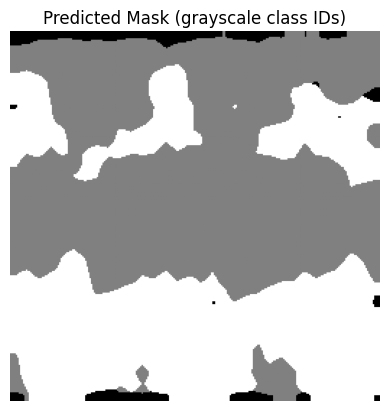

In [359]:
mask = pred_classes_backbone_freeze[2].cpu().numpy()  # shape [H, W]

# Display class indices (0, 1, 2)
plt.imshow(mask, cmap='gray')
plt.title("Predicted Mask (grayscale class IDs)")
plt.axis('off')
plt.show()

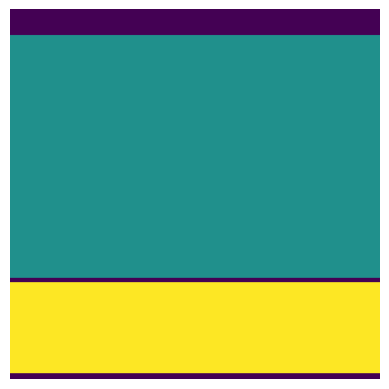

In [360]:
plt.imshow(test_fine_labels_reader[2])
plt.axis('off')  
plt.show()